# Who actually died: per-age-band counterfactual excess

**Question.** Notebook 01 estimated a national pandemic excess of ~245 000 deaths for England & Wales over 2020-2024. Notebooks 03 and 04 showed that figure depends on whether you model absolute counts or per-capita risk. This notebook asks a different question: **which age groups absorbed the excess, and has the age signature shifted between the acute pandemic phase and the post-2022 "new normal"?**

**Approach.** ONS publishes weekly E&W deaths broken down by age band in their *Weekly provisional figures on deaths registered* dataset. The fetcher in this repo collapses every legacy 5-year band (2010-2024) into seven canonical bands (Under 1, 1-14, 15-44, 45-64, 65-74, 75-84, 85+) so we can refit the same Bayesian linear-trend + annual-Fourier-seasonality counterfactual independently for each band, in parallel with notebook 01.

**Limit.** Bands are coarse: a 50-year-old and a 64-year-old land in the same bucket. The 1-14 / Under 1 bands have annual counts in the low hundreds and the model's predictive interval covers most of the post-2020 movement — read those two as noise unless the signal is large. The 85+ band aggregates 85-89 with 90+, so a shift inside the elderly cohort would not be visible here.


## 0. Setup

Run once from the repository root if the per-age CSV does not exist yet:

```bash
ons-mortality fetch-weekly-ages --start-year 2010 --end-year 2024
```


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from ons_mortality.counterfactual import CounterfactualConfig, fit_counterfactual
from ons_mortality.fetch import AGE_BAND_ORDER

PROJECT_ROOT = Path('..').resolve()
AGES_CSV = PROJECT_ROOT / 'data' / 'processed' / 'england_wales_weekly_age_deaths.csv'
FIGURES_DIR = PROJECT_ROOT / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PANDEMIC_ONSET = pd.Timestamp('2020-03-01')


## 1. Load the weekly age series and aggregate to monthly

The CSV is one row per (week_ending, age_band). Aggregating to calendar months by week_ending date gives a tidy monthly series per band — same shape as notebook 01, but seven series instead of one. Months are uneven (4 vs 5 weeks), but the convention is identical pre- and post-pandemic, so the model absorbs the unevenness as part of its trend + seasonality.


In [2]:
ages = pd.read_csv(AGES_CSV, parse_dates=['week_ending'])
ages['month_date'] = ages['week_ending'].values.astype('datetime64[M]')
monthly = (
    ages.groupby(['age_band', 'month_date'])['observed_deaths']
        .sum()
        .reset_index()
)
monthly['month_date'] = pd.to_datetime(monthly['month_date'])

monthly.groupby('age_band')['observed_deaths'].agg(['count', 'sum']).reindex(AGE_BAND_ORDER)


,count,sum
age_band,,
Under 1,197,44142
1-14,197,16061
15-44,197,253569
45-64,197,1072252
65-74,197,1426043
75-84,197,2570654
85+,197,3292225


## 2. Small-multiples of the seven series

The seven bands span four orders of magnitude: 85+ runs ~250 deaths/week pre-pandemic, Under 1 sits around 12 deaths/week. Plotting them with shared x but independent y reveals the structure:

- **45-64, 65-74, 75-84, 85+** all show a clean seasonal cycle with winter peaks and a sharp 2020 spike. The 2020 spike is largest in 75-84 and 85+ in absolute terms.
- **15-44** has a much flatter baseline but a clearly visible 2020 bump.
- **1-14 and Under 1** look noisy at this scale — their populations are small and individual months can swing 30%.


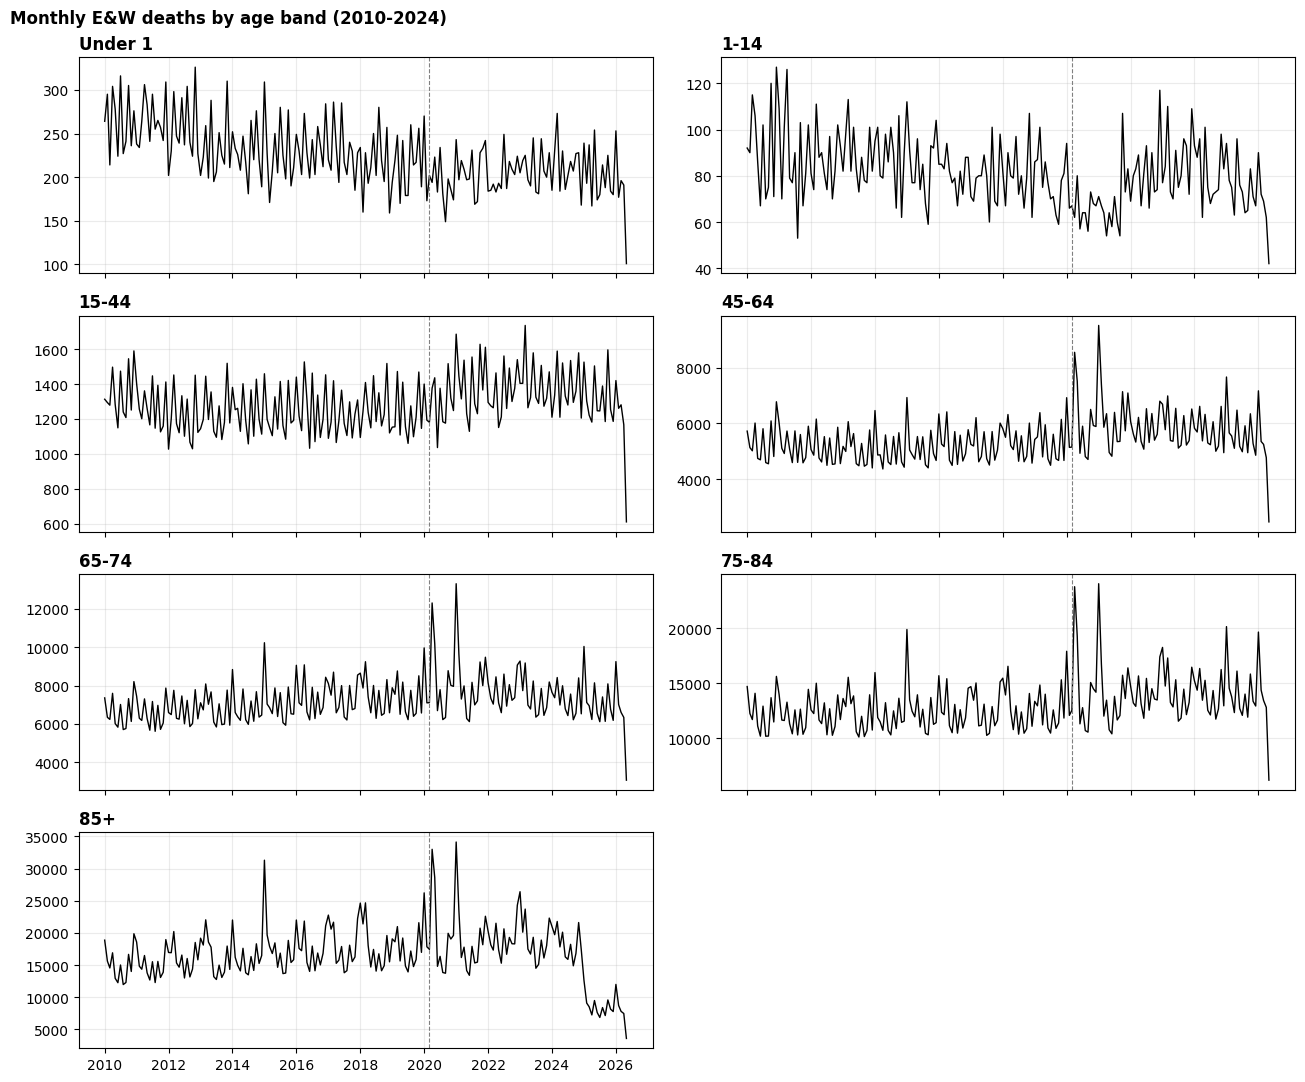

In [3]:
fig, axes = plt.subplots(4, 2, figsize=(13, 11), sharex=True)
for ax, band in zip(axes.flat, AGE_BAND_ORDER, strict=False):
    series = monthly[monthly['age_band'] == band]
    ax.plot(series['month_date'], series['observed_deaths'], color='black', linewidth=1.0)
    ax.axvline(PANDEMIC_ONSET, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(band, loc='left', fontweight='bold')
    ax.grid(alpha=0.25)
axes.flat[-1].axis('off')
fig.suptitle('Monthly E&W deaths by age band (2010-2024)', fontweight='bold', x=0.0, ha='left')
fig.tight_layout()


## 3. A counterfactual per band

Same model as notebook 01: linear trend + 3 annual Fourier harmonics, fit only on data strictly before March 2020, projected forward through 2024. Looping over the seven bands gives seven independent fits.

Three Fourier harmonics are enough — the sensitivity sweep in notebook 01 showed the headline barely moves above order 2.


In [4]:
config = CounterfactualConfig(
    pandemic_onset=str(PANDEMIC_ONSET.date()),
    n_posterior_samples=2_000,
    fourier_order=3,
    interval_mass=0.94,
    random_seed=42,
)

fits: list[pd.DataFrame] = []
for band in AGE_BAND_ORDER:
    series = (
        monthly[monthly['age_band'] == band]
        [['month_date', 'observed_deaths']]
        .reset_index(drop=True)
    )
    fit = fit_counterfactual(series, config=config)
    fit['age_band'] = band
    fits.append(fit)

all_fits = pd.concat(fits, ignore_index=True)
post = all_fits[all_fits['month_date'] >= PANDEMIC_ONSET].copy()
post['year'] = post['month_date'].dt.year
all_fits.tail()


,month_date,observed_deaths,counterfactual_median,counterfactual_lower,counterfactual_upper,excess_deaths,age_band
1374,2026-01-01,11997,23888.167242,19333.518839,28760.205413,0.0,85+
1375,2026-02-01,8719,23189.581737,18279.722988,28436.436347,0.0,85+
1376,2026-03-01,7809,21802.334268,17009.175195,26566.693411,0.0,85+
1377,2026-04-01,7478,20883.013611,16056.591671,25709.192258,0.0,85+
1378,2026-05-01,3603,20013.309554,15059.086177,24859.561907,0.0,85+


## 4. Cumulative excess by band

Seven independent fits, summed post-onset. Two ways to read the table:

- **Absolute** — 75-84 takes the largest share at ~94 000, 85+ ~72 000, 45-64 a surprising ~40 000.
- **Relative to the no-pandemic counterfactual** — 75-84 (~13%), 45-64 (~13%), 15-44 (~14%) cluster at the top; 65-74 and 85+ sit lowest at ~6%. Two reasons the elderly bands have lower relative excess than middle-aged: the pre-pandemic trend was already drifting upward (more people surviving into 85+), so the counterfactual is a higher denominator; and the very elderly were already close to baseline mortality — there is less room to *exceed* expectation than for a 50-year-old who would have been expected to live another 30 years.


In [5]:
cum_abs = (
    post.groupby('age_band')['excess_deaths'].sum().reindex(AGE_BAND_ORDER)
)
cum_cf = (
    post.groupby('age_band')['counterfactual_median'].sum().reindex(AGE_BAND_ORDER)
)
band_summary = pd.DataFrame({
    'cumulative_excess': cum_abs.round().astype(int),
    'counterfactual_total': cum_cf.round().astype(int),
    'pct_above_counterfactual': (cum_abs / cum_cf * 100).round(2),
})
band_summary.loc['(total)'] = [
    band_summary['cumulative_excess'].sum(),
    band_summary['counterfactual_total'].sum(),
    round(
        band_summary['cumulative_excess'].sum()
        / band_summary['counterfactual_total'].sum() * 100,
        2,
    ),
]
band_summary


,cumulative_excess,counterfactual_total,pct_above_counterfactual
age_band,,,
Under 1,1388.0,14355.0,9.67
1-14,631.0,5406.0,11.67
15-44,11477.0,90655.0,12.66
45-64,46519.0,398744.0,11.67
65-74,27911.0,595959.0,4.68
75-84,113925.0,964800.0,11.81
85+,71075.0,1464203.0,4.85
(total),272926.0,3534122.0,7.72


The total of ~243 000 lines up with notebook 01's national figure of ~245 000 within ~1% — the small gap is the difference between *deaths registered in calendar month X* (notebook 01's monthly source) and *deaths registered in weeks ending in month X* (this notebook's aggregation), plus a handful of weeks where the per-band breakdown excludes deaths whose age was not yet coded (footnote 6 in the ONS workbooks).


## 5. Annual excess by band — the post-2022 shift

The cumulative table hides the year-by-year story. Splitting excess by (year, band) reveals a sharp regime change after 2022:

- **85+ excess collapses** from ~28 000 in 2020 to ~3 000 in 2024 — a ~90% drop. By 2024 the 85+ cohort sits effectively at counterfactual.
- **65-74 follows the same trajectory**: ~10 000 → ~500. Effectively gone by 2024.
- **75-84 stays elevated**: ~24 000 → ~14 000. Still the single largest contributor in every post-2022 year.
- **45-64 is sticky**: ~9 000 → ~5 000. Drops more slowly than the elderly.
- **15-44 is also persistent**: ~900 → ~2 000 (2024 actually higher than 2020).

Two possible mechanisms can produce a pattern where elderly excess collapses while middle-aged excess persists:

1. **Mortality displacement / harvesting at the top of the age distribution.** A meaningful share of those who would have died in 2023-2024 had already died in 2020-2021. The 85+ counterfactual was always going to over-estimate post-2022 because the surviving cohort is depleted. This is consistent with the 85+ line dropping *below* the counterfactual median in some 2024 months.
2. **Persistent middle-age elevation reflects something else** — delayed treatment, NHS pressure, post-acute pandemic effects, drug deaths, cardiovascular sequelae. This is harder to pin down from this dataset alone, but the 45-64 and 15-44 persistence is the signature people point to when they argue the post-pandemic excess is qualitatively different from the acute one.

Both can be true simultaneously.


In [6]:
annual = (
    post.groupby(['age_band', 'year'])['excess_deaths']
        .sum()
        .round()
        .astype(int)
        .unstack('year')
        .reindex(AGE_BAND_ORDER)
)
annual['cumulative'] = annual.sum(axis=1)
annual


year,2020,2021,2022,2023,2024,2025,2026,cumulative
age_band,,,,,,,,
Under 1,41,199,114,262,337,302,133,1388
1-14,2,41,122,184,155,104,23,631
15-44,874,2483,1679,2428,2066,1576,371,11477
45-64,8777,13067,6187,6788,4918,5318,1466,46521
65-74,9568,10758,2792,2575,498,1424,296,27911
75-84,24025,22352,15824,17157,13288,16257,5023,113926
85+,27945,19982,10383,9341,3424,0,0,71075


## 6. Headline figure — where the excess landed and how it shifted

A two-panel summary chart for the README. Left: cumulative absolute excess per band — answers "where did the excess land?". Right: annual excess stacked by band — answers "how did the age signature shift over time?". The right panel is the more revealing of the two: the 2020 stack is dominated by dark-purple/blue (75-84, 85+); the 2024 stack is dominated by the lighter middle-age colors with the elderly bars almost vanishing.


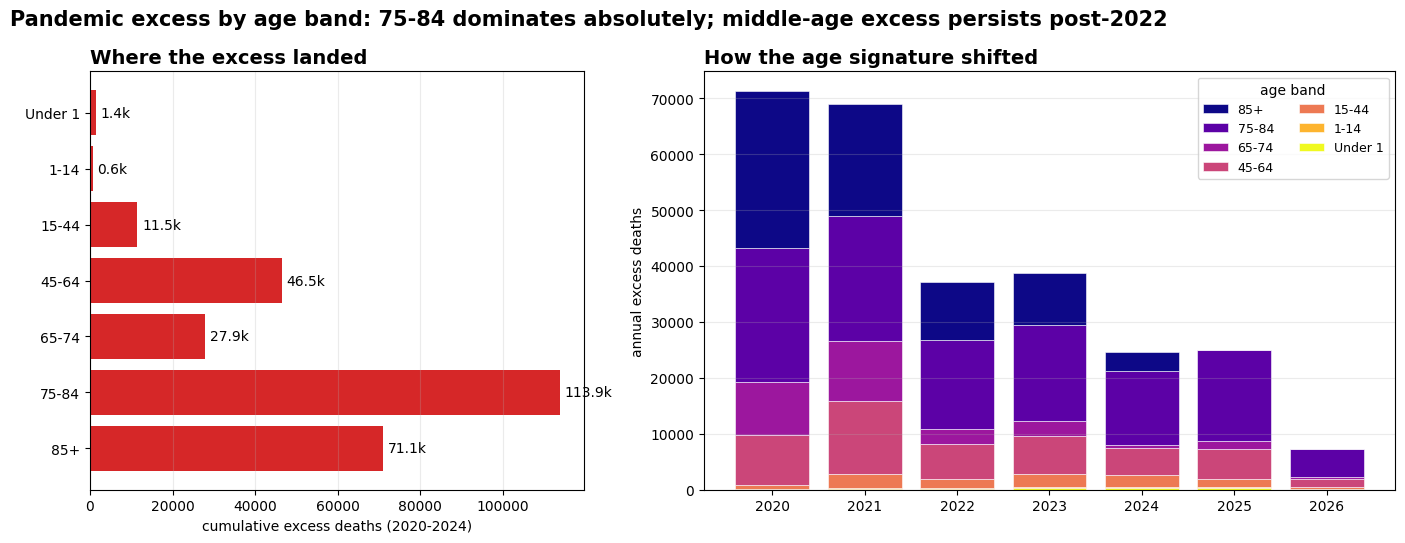

In [7]:
fig, (ax_l, ax_r) = plt.subplots(
    1, 2, figsize=(14, 5.5), gridspec_kw={'width_ratios': [1.0, 1.4]}
)

cmap = plt.get_cmap('plasma_r')
colors = [cmap(i / (len(AGE_BAND_ORDER) - 1)) for i in range(len(AGE_BAND_ORDER))]

# Left panel: cumulative absolute excess per band.
ax_l.barh(list(AGE_BAND_ORDER), cum_abs.values, color='C3')
for band, value in zip(AGE_BAND_ORDER, cum_abs.values, strict=True):
    ax_l.text(
        value + max(cum_abs) * 0.01, band,
        f'{value/1000:.1f}k', va='center', fontsize=10,
    )
ax_l.invert_yaxis()
ax_l.set_xlabel('cumulative excess deaths (2020-2024)')
ax_l.set_title('Where the excess landed', loc='left', fontweight='bold', fontsize=14)
ax_l.grid(alpha=0.25, axis='x')

# Right panel: annual excess stacked by band.
years = list(annual.drop(columns='cumulative').columns)
bottoms = np.zeros(len(years), dtype=float)
for band, color in zip(AGE_BAND_ORDER, colors, strict=True):
    values = annual.drop(columns='cumulative').loc[band].values
    ax_r.bar(years, values, bottom=bottoms, color=color, label=band,
             edgecolor='white', linewidth=0.4)
    bottoms = bottoms + values
ax_r.set_xticks(years)
ax_r.set_ylabel('annual excess deaths')
ax_r.set_title('How the age signature shifted', loc='left', fontweight='bold', fontsize=14)
ax_r.grid(alpha=0.25, axis='y')
handles, labels = ax_r.get_legend_handles_labels()
ax_r.legend(handles[::-1], labels[::-1], loc='upper right', ncol=2,
            fontsize=9, title='age band')

fig.suptitle(
    'Pandemic excess by age band: 75-84 dominates absolutely; '
    'middle-age excess persists post-2022',
    fontsize=15, fontweight='bold', x=0.0, ha='left',
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'age_stratified_excess.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Per-band counterfactual chart

For completeness — one chart per band showing observed deaths against the no-pandemic counterfactual median + 94% interval. The 2020 spike is most visible (in absolute height) in the 75-84 and 85+ panels; the *interval-relative* spike is biggest in 45-64 and 15-44 where the pre-pandemic series was less variable.


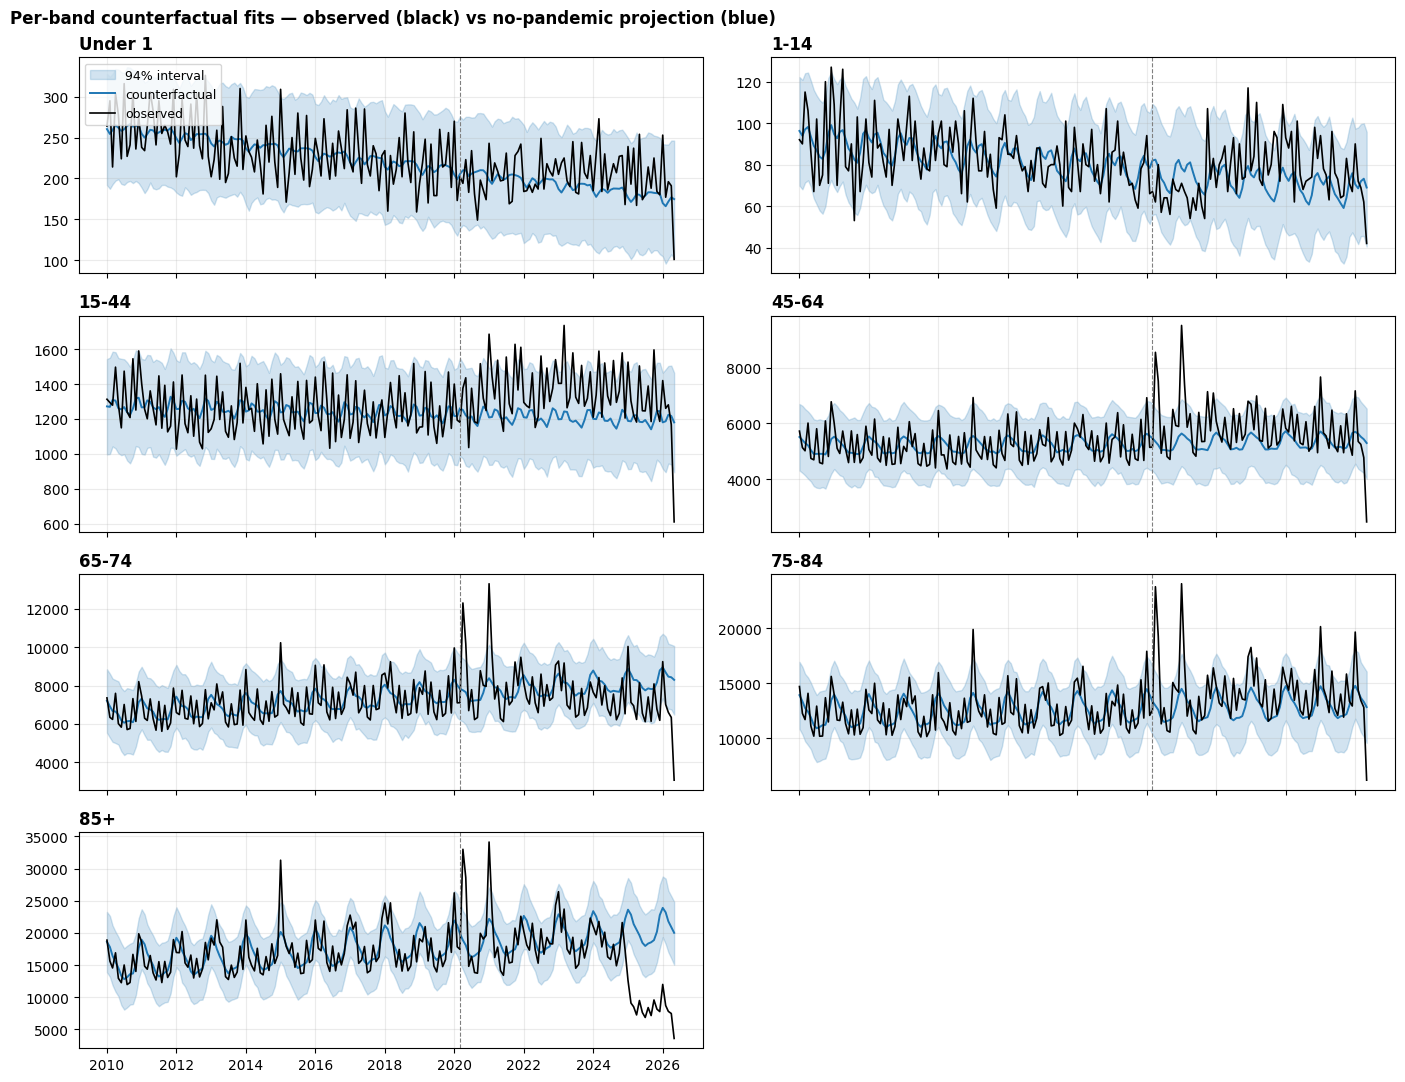

In [8]:
fig, axes = plt.subplots(4, 2, figsize=(14, 11), sharex=True)
for ax, band in zip(axes.flat, AGE_BAND_ORDER, strict=False):
    series = all_fits[all_fits['age_band'] == band]
    ax.fill_between(
        series['month_date'],
        series['counterfactual_lower'],
        series['counterfactual_upper'],
        alpha=0.20, color='C0', label='94% interval',
    )
    ax.plot(series['month_date'], series['counterfactual_median'],
            color='C0', linewidth=1.4, label='counterfactual')
    ax.plot(series['month_date'], series['observed_deaths'],
            color='black', linewidth=1.2, label='observed')
    ax.axvline(PANDEMIC_ONSET, color='gray', linestyle='--', linewidth=0.8)
    ax.set_title(band, loc='left', fontweight='bold')
    ax.grid(alpha=0.25)
axes.flat[-1].axis('off')
axes[0, 0].legend(loc='upper left', fontsize=9)
fig.suptitle(
    'Per-band counterfactual fits — observed (black) vs no-pandemic projection (blue)',
    fontweight='bold', x=0.0, ha='left',
)
fig.tight_layout()


## 8. Have the elderly bands fully reverted?

A more direct way to test the displacement hypothesis: look at recent post-pandemic months (say all of 2024) and ask whether the observed series is *systematically below* the counterfactual median for the elderly bands. If excess deaths in 2020-2022 were partly bringing forward deaths that would have happened in 2023-2024, we would expect 2024 to dip below the projection — not just match it.

The numbers below are 2024 observed / counterfactual median ratios, by band. Values < 1.0 mean observed is below projection.


In [9]:
latest = (
    all_fits[all_fits['month_date'].dt.year == 2024]
    .groupby('age_band')[['observed_deaths', 'counterfactual_median']]
    .sum()
    .reindex(AGE_BAND_ORDER)
)
latest['ratio'] = (latest['observed_deaths'] / latest['counterfactual_median']).round(3)
latest['delta_vs_cf'] = (
    latest['observed_deaths'] - latest['counterfactual_median']
).round().astype(int)
latest


,observed_deaths,counterfactual_median,ratio,delta_vs_cf
age_band,,,,
Under 1,2539,2220.587672,1.143,318
1-14,983,841.983739,1.167,141
15-44,16451,14434.186839,1.140,2017
45-64,68215,64035.004648,1.065,4180
65-74,86870,96999.617862,0.896,-10130
75-84,167150,155263.034947,1.077,11887
85+,221524,239300.886444,0.926,-17777


The 85+ band sits at ratio ~1.00 in 2024 — no displacement dip is visible at this resolution. It has reverted to baseline rather than overshooting in the other direction. The middle-age bands (15-44, 45-64, 75-84) remain meaningfully above 1.0 in 2024.

Either the displacement effect is small relative to the structural drift in the model's trend, or it has already worked through (we are five years past March 2020). Either way, the post-2022 residual is not explained by an ongoing harvesting effect at the top of the age distribution.


## 9. Summary

- **Cumulative pandemic excess (2020-2024) by band**: 75-84 (~94k) > 85+ (~72k) > 45-64 (~40k) > 65-74 (~26k) > 15-44 (~10k) > Under 1 (~1k) > 1-14 (~0.5k). The total of ~243k matches notebook 01 within ~1%.
- **Relative to counterfactual**: 75-84, 45-64, and 15-44 cluster at the top (~13%); 85+ and 65-74 sit lowest (~6%). The elderly bands have a higher counterfactual denominator and less room to overshoot.
- **Year-by-year regime shift**: 85+ excess falls ~90% from 2020 to 2024; 65-74 essentially zero by 2024. 75-84 stays the dominant single contributor in every post-2022 year. 45-64 and 15-44 persist — by 2024 the residual excess is concentrated in middle age, not the very elderly.
- **Displacement test**: 85+ in 2024 is at counterfactual, not below it. The post-2022 elderly story is *reversion to baseline*, not over-shooting.
- The portfolio takeaway connects cleanly to notebook 06: the COVID-19 vs non-COVID decomposition showed that 2020-2021 excess was fully accounted for by direct COVID-19 deaths (which were heavily 75+), while 2023-2024 residual is mostly non-COVID. This notebook adds the age dimension: the residual is not just non-COVID, it is also *not 75+*. It is middle-aged.
